
<h1 align="center"> Statistics and Financial Data Analysis
<h1 align="center"> Examples


In [1]:
import pandas_datareader as pd_data
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import math
import scipy as sp
import statsmodels.api as sm
from statsmodels.distributions.empirical_distribution import ECDF
from statsmodels.stats.anova import anova_lm
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)



In [2]:
df = pd.read_csv('WeekInt.csv')

In [3]:
df.head()

,mo,nth,day y,ear ff,tb03,cm10,cm30,discount,prime,aaa,xxx
0,2,16,77,4.70,4.62,7.36,7.69,5.25,6.25,8.04,105.30
1,2,23,77,4.74,4.67,7.39,7.75,5.25,6.25,8.08,105.24
2,3,2,77,4.68,4.70,7.47,7.81,5.25,6.25,8.10,105.30
3,3,9,77,4.63,4.64,7.49,7.82,5.25,6.25,8.12,105.26
4,3,16,77,4.62,4.59,7.45,7.80,5.25,6.25,8.09,105.40


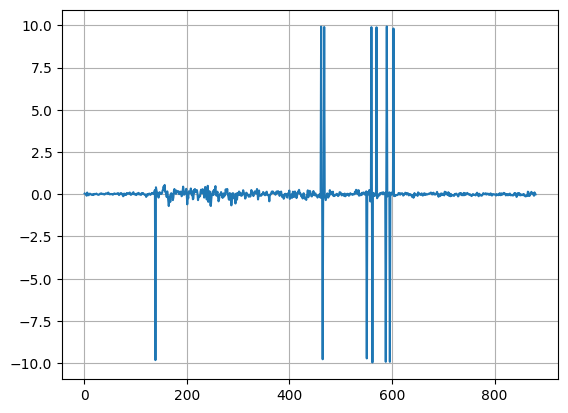

In [4]:
df['aaa_diff']= df['aaa'].diff().dropna()
df['cm10_diff']= df['cm10'].diff().dropna()
plt.plot(df['aaa_diff'])
plt.grid()

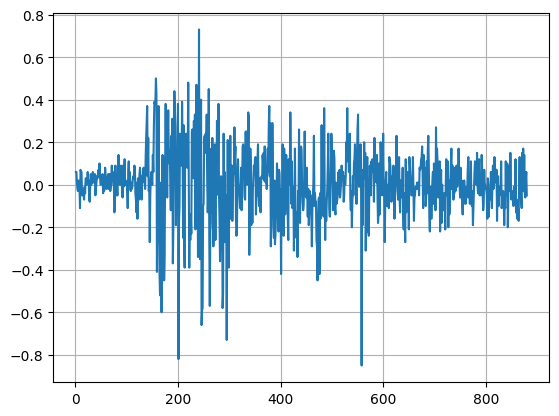

In [5]:
df['cm30_diff']= df['cm30'].diff().dropna()
plt.plot(df['cm30_diff'])
plt.grid()

In [6]:
# Filter data:
q_low = df['aaa_diff'].quantile(0.01)
q_high = df['aaa_diff'].quantile(0.99)
q_low

-0.6362999999999999

In [7]:
df_filtered = df[(df['aaa_diff'] < q_high ) & (df['aaa_diff'] > q_low)]

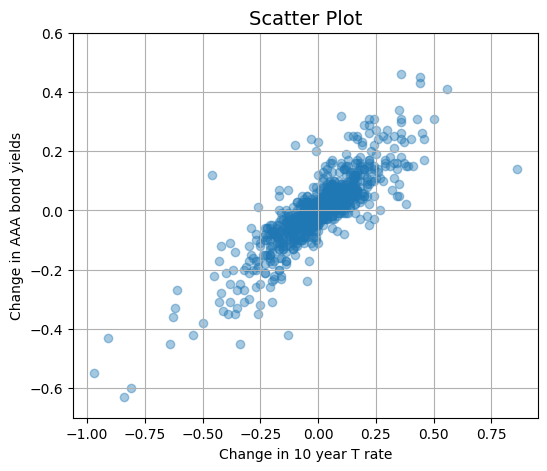

In [8]:
plt.figure(figsize=(6,5))
X = df_filtered['cm10_diff']
y = df_filtered['aaa_diff']
plt.scatter(X,y,marker = 'o', alpha = 0.4)
plt.title('Scatter Plot', size = 14)
plt.xlabel('Change in 10 year T rate')
plt.ylabel('Change in AAA bond yields')
plt.ylim(-0.7,0.6)
plt.grid()

In [9]:
X = df_filtered['cm10_diff']
y = df_filtered['aaa_diff']
Xnew = sm.add_constant(X)
model_1 = sm.OLS(y, Xnew).fit()
y_fitted = model_1.predict(Xnew)

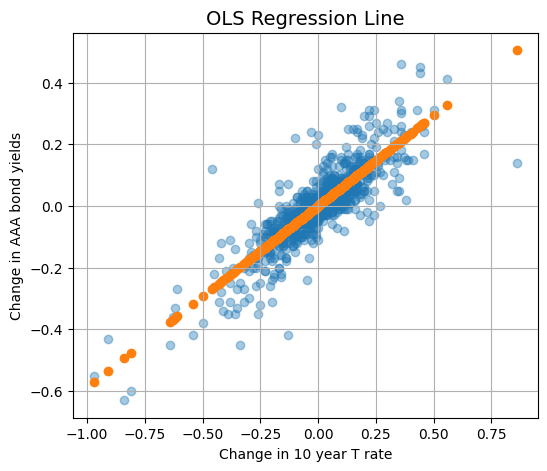

In [10]:
plt.figure(figsize=(6,5))
plt.scatter(X,y,marker = 'o', alpha = 0.4)
plt.scatter(X,y_fitted)
plt.title('OLS Regression Line', size = 14)
plt.xlabel('Change in 10 year T rate')
plt.ylabel('Change in AAA bond yields')
plt.grid()

In [11]:
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               aaa_diff   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.721
Method:                 Least Squares   F-statistic:                     2221.
Date:                Sun, 02 Oct 2022   Prob (F-statistic):          1.57e-240
Time:                        11:46:21   Log-Likelihood:                 1149.6
No. Observations:                 862   AIC:                            -2295.
Df Residuals:                     860   BIC:                            -2286.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9.785e-06      0.002      0.004      0.996      -0.004       0.004
cm10_diff      0.5871      0.012     47.129      0.000       0.563       0.612
==============================================================================
Omnibus:                      111.997   Durbin-Watson:                   2.096
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1063.520
Skew:                           0.143   Prob(JB):                    1.15e-231
Kurtosis:                       8.434   Cond. No.                         5.73
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

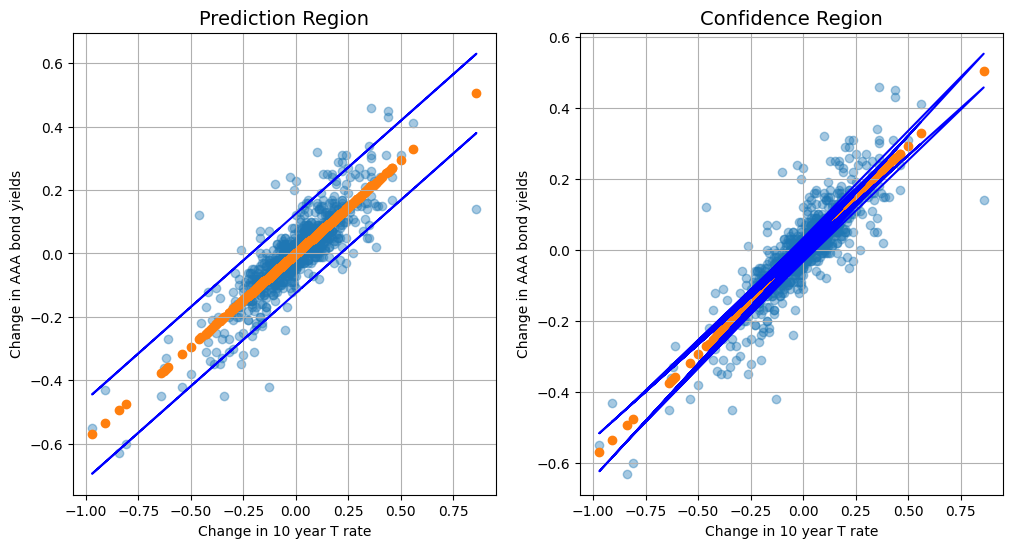

In [12]:
#Prediction interval

X = df_filtered['cm10_diff']
y = df_filtered['aaa_diff']
Xnew = sm.add_constant(X)
model_1 = sm.OLS(y, Xnew).fit()
y_fitted = model_1.predict(Xnew)

res = model_1.resid

model_pred_y_up = y_fitted + 1.96*np.std(res)
model_pred_y_down = y_fitted - 1.96*np.std(res)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(X,y,marker = 'o', alpha = 0.4)
plt.scatter(X,y_fitted)
plt.plot(X,model_pred_y_up, color = 'blue')
plt.plot(X,model_pred_y_down, color = 'blue')

plt.title('Prediction Region', size = 14)
plt.xlabel('Change in 10 year T rate')
plt.ylabel('Change in AAA bond yields')
plt.grid()

#Confidence interval
n = len(X)

model_pred_y_up = np.zeros(n)
model_pred_y_down = np.zeros(n)
s_x = X.std()*np.sqrt(n)

for i in range(n):
    model_pred_y_up[i] = y_fitted.iloc[i] + 1.96*np.std(res)*np.sqrt(X.iloc[i]*X.iloc[i]/s_x)
    model_pred_y_down[i] = y_fitted.iloc[i] - 1.96*np.std(res)*np.sqrt(X.iloc[i]*X.iloc[i]/s_x)

plt.subplot(1,2,2)
plt.scatter(X,y,marker = 'o', alpha = 0.4)
plt.scatter(X,y_fitted)
plt.plot(X,model_pred_y_up, color = 'blue')
plt.plot(X,model_pred_y_down, color = 'blue')

plt.title('Confidence Region', size = 14)
plt.xlabel('Change in 10 year T rate')
plt.ylabel('Change in AAA bond yields')
plt.grid()

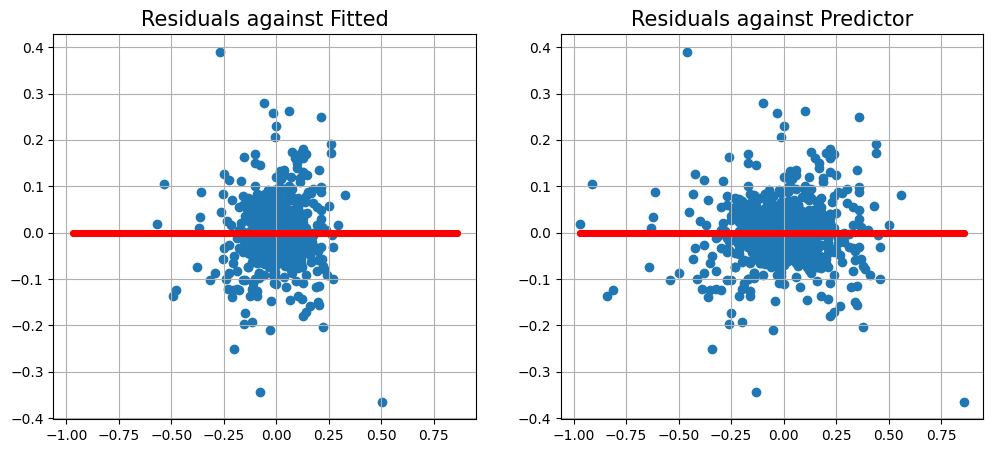

In [13]:
y_fitted = model_1.predict(Xnew) # make the predictions by the model
res = model_1.resid

plt.figure(figsize=(12,5))
plt.subplot(1,2, 1)
plt.scatter(y_fitted,res)
plt.plot(X,np.zeros(n),'r',linewidth = 5)
plt.title('Residuals against Fitted', fontsize = 15)
plt.grid()
plt.subplot(1,2, 2)
plt.scatter(X,res)
plt.plot(X,np.zeros(n),'r',linewidth = 5)
plt.title('Residuals against Predictor', fontsize = 15)
plt.grid()
#plt.savefig("Resid_NoCorrelation")

Text(0.5, 1.0, 'QQ Plot')

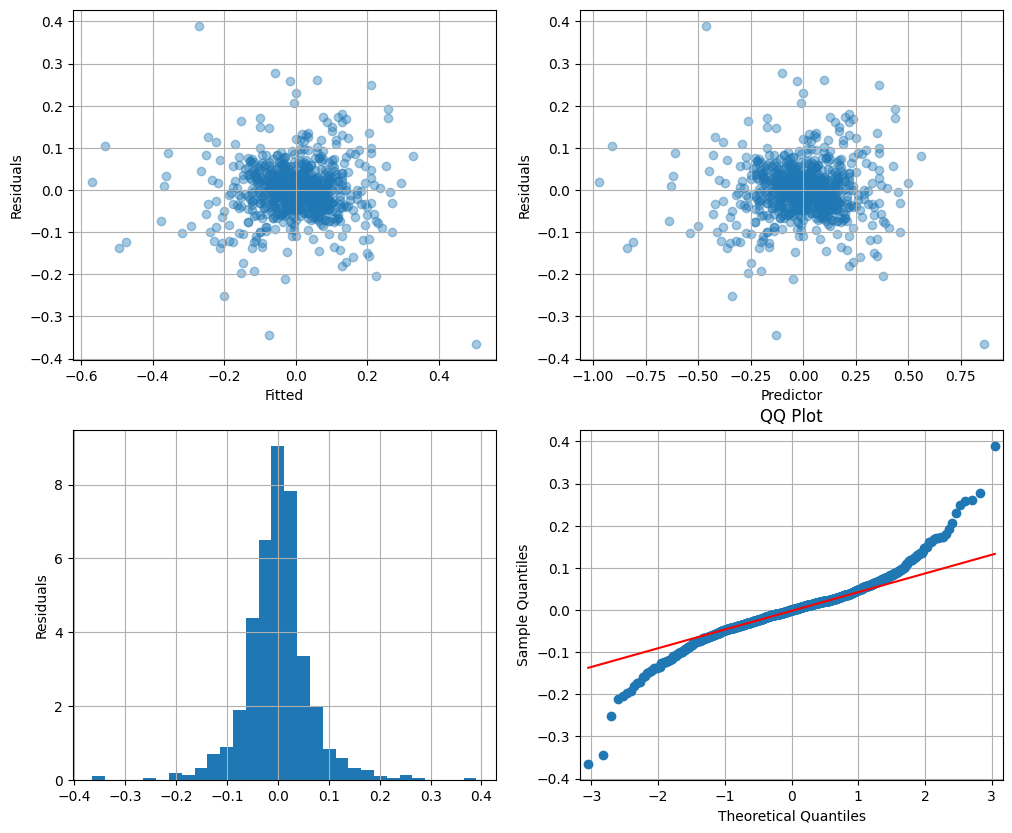

In [16]:

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,10))
ax= axes.flatten()

#fig.suptitle("A few diagnostic plots", size = 15)

ax[0].scatter(y_fitted, res, marker = 'o', alpha = 0.4)
ax[0].grid()
ax[0].set(xlabel = 'Fitted', ylabel = 'Residuals')

ax[1].scatter(X, res, marker = 'o', alpha = 0.4)
ax[1].grid()  
ax[1].set(xlabel = 'Predictor', ylabel = 'Residuals')


ax[2].hist(res, bins = 30, density = True)
ax[2].grid()
ax[2].set(ylabel = 'Residuals')


sm.qqplot(res, fit = True, line='q',ax = ax[3])
ax[3].grid()
ax[3].set_title("QQ Plot")

